In this notebook we design a very basic LnagGraph workflow

In [3]:
#install langGraph 
!pip install langgraph -q

Simple Graph to greet the user

In [9]:
#defien the strucutre of the data that the graph will carry. 
#agent/graph state is a dictionary, and it must have a key called name, where the value should be a string
from typing import TypedDict
class AgentState(TypedDict):
    name: str

In [12]:
# This function receives the current graph state, reads the user's name,
# updates the name value by adding a greeting message, and returns the updated state.
def hello(state:AgentState)->AgentState:
    state['name']=f"Hello {state['name']}!"
    return state

In [14]:
#import the Stategraph, start and end from the langgraph 
from langgraph.graph import StateGraph, START,END

In [26]:
#create the workflow, we gie the strucutre of data we want to keep in this state
workflow=StateGraph(AgentState)
#add hello function to the workflow as a node. here "hellofuction" is the node name . e add the hello function here
workflow.add_node("hellofunction",hello)
#create the first edge from start to hellow node
workflow.add_edge(START,"hellofunction")
#create the last edge from hello to end
workflow.add_edge("hellofunction",END)

#complie the graph
app=workflow.compile()

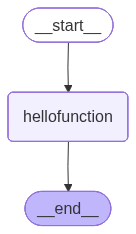

In [27]:
#visualize the created graph
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
#use the app now. her we give in assigned dict format
result=app.invoke({"name":"Sharadhi"})
print(result['name'])

Hello Sharadhi!


In [31]:
#When we have multiple inputs, like name and age. then we need to greet accoridngly. we change the AgentState and the hello class accrodingly
from typing import TypedDict
class AgentStateAdv(TypedDict):
    name: str #input name
    age: int #input age
    message: str #greeting msg

In [40]:
def helloAdv(state:AgentStateAdv)->AgentStateAdv:
    state['message']=f"Hello {state['name']}! Your age is {state['age']}"
    return state

In [48]:
from langgraph.graph import StateGraph, START,END

In [41]:
#create the workflow, we gie the strucutre of data we want to keep in this state
workflowNew=StateGraph(AgentStateAdv)
#add hello function to the workflow as a node. here "hellofuction" is the node name . e add the hello function here
workflowNew.add_node("newhellofunction",helloAdv)
#create the first edge from start to hellow node
workflowNew.add_edge(START,"newhellofunction")
#create the last edge from hello to end
workflowNew.add_edge("newhellofunction",END)

#complie the graph
appNew=workflowNew.compile()

In [45]:
#use the app now. her we give in assigned dict format
resultNew=appNew.invoke({"name":"Sharadhi","age":33})
print(resultNew['message'])

Hello Sharadhi! Your age is 33


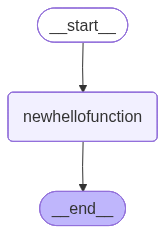

In [46]:
#visualize the created graph
from IPython.display import Image,display
display(Image(appNew.get_graph().draw_mermaid_png()))

Create a sequential graph for give the greeting message for name and age

In [47]:
# we create two functions for name and age
def helloName(state:AgentStateAdv)->AgentStateAdv:
    state['message']=f"Hello {state['name']}!"
    return state

def helloAge(state:AgentStateAdv)->AgentStateAdv:
    state['message']=f"{state['message']}. Your age is {state['age']}."
    return state

In [50]:
# now create two nodes
workflowSeq=StateGraph(AgentStateAdv)

workflowSeq.add_node("helloName",helloName)
workflowSeq.add_node("helloAge",helloAge)
#create the first edge from start to hellow node
workflowSeq.add_edge(START,"helloName")
workflowSeq.add_edge("helloName","helloAge")
#create the last edge from hello to end
workflowSeq.add_edge("helloAge",END)

#complie the graph
appSeq=workflowSeq.compile()

In [51]:
#use the app now. her we give in assigned dict format
resultSeq=appSeq.invoke({"name":"Sharadhi","age":33})
print(resultSeq['message'])

Hello Sharadhi!. Your age is 33.


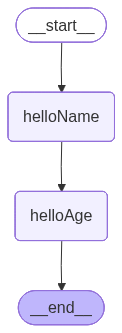

In [52]:
#visualize the created graph
from IPython.display import Image,display
display(Image(appSeq.get_graph().draw_mermaid_png()))

Create a conditional graph. we give two numbers , there are operations for addition, subtraction, multiplication and division. we have aconditional grpah to do these work

In [53]:
class AgentConditional(TypedDict):
    num1:int
    num2:int
    operation: str
    result: int

In [57]:
# create node classes for addition, subtraction, multiplication and division
def addition(state:AgentConditional)->AgentConditional:
    state['result']=state['num1']+state['num2']
    return state

def subtraction(state:AgentConditional)->AgentConditional:
    state['result']=state['num1']-state['num2']
    return state

def multiplication(state:AgentConditional)->AgentConditional:
    state['result']=state['num1']*state['num2']
    return state

def division(state:AgentConditional)->AgentConditional:
    state['result']=state['num1']/state['num2']
    return state

#create the conditional node for decision making
def decision_node(state:AgentConditional)->AgentConditional:
    if state["operation"]=="+":
        return "addition_operation"# says it goes to edge for the addtion. we will create the edge with this same name later in the workflow
    if state["operation"]=="-":
        return "subtraction_operation"
    if state["operation"]=="*":
        return "multiplication_operation"
    if state["operation"]=="/":
        return "division_operation"
    return state

In [61]:
workflowConditional=StateGraph(AgentConditional)

#defien nodes
workflowConditional.add_node("addition",addition)
workflowConditional.add_node("subtraction",subtraction)
workflowConditional.add_node("multiplication",multiplication)
workflowConditional.add_node("division",division)
#in the router node, we returne  ege, not a state. so we need to have a lamda
workflowConditional.add_node("router",lambda state:state)

#edges
workflowConditional.add_edge(START,"router")
#create the connditional edge
workflowConditional.add_conditional_edges("router",decision_node,{"addition_operation":"addition","subtraction_operation":"subtraction","multiplication_operation":"multiplication","division_operation":"division"})
workflowConditional.add_edge("addition",END)
workflowConditional.add_edge("subtraction",END)
workflowConditional.add_edge("multiplication",END)
workflowConditional.add_edge("division",END)
#complie the graph
appConditional=workflowConditional.compile()

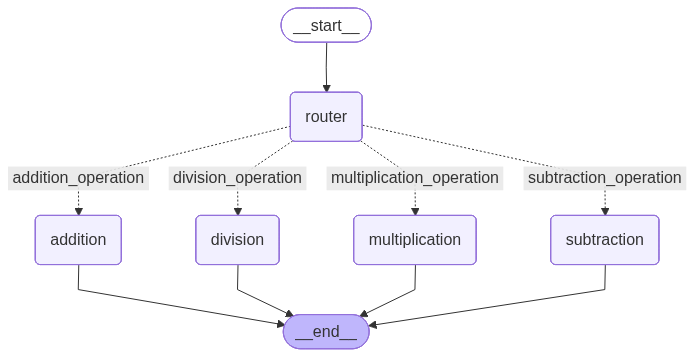

In [62]:
#visualize the created graph
from IPython.display import Image,display
display(Image(appConditional.get_graph().draw_mermaid_png()))

In [68]:
#use the app now. her we give in assigned dict format
resultConditional=appConditional.invoke({"num1":34,"num2":33,"operation":"/"})
print(resultConditional['result'])

1.0303030303030303
